

> # 데이터 전처리






필요한 라이브러리 가져오기

In [ ]:
from google.colab import drive #드라이브 마운트
drive.mount('/content/drive')

import re                     #각종 필요한 라이브러리
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
import plotly.express as px

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install urlextract      #url
!pip install emoji~=1.6.3    #이모지
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

각자 입력해야하는 칸

In [ ]:
######각자의 카톡데이터파일이 있는 경로 입력
f_path = '/content/drive/MyDrive/Colab Notebooks/카카오톡데이터분석팀플'


#머신러닝모델 테스트용 파일 이름
test_name = '차지훈'

######각자 파일들의 .txt를 뺀 이름 입력 (각 파일 이름을 사람이름과 같게, 친밀도 높은 순대로)
files = [
    ##############################################


    '서민호','이도현','오진우','김세현','김도윤','허지환','오승환','유승원','엄마','아빠'
    ##############################################

    ,test_name
]
#예시 '홍길동','임꺽정','김철수'





####자신의 카카오톡 이름(user_name에서 자신이 한 대화에 뜨는 이름)
myname= '송창훈'

*카카오톡* 데이터 가져오기

In [ ]:



def katalk_msg_parse(file_path):#카톡파싱함수
  my_katalk_data = list()
  katalk_msg_pattern = "[0-9]{4}[년.] [0-9]{1,2}[월.] [0-9]{1,2}[일.] (오전|오후) [0-9]{1,2}:[0-9]{1,2}, .*:"
  date_info = "[0-9]{4}[년.] [0-9]{1,2}[월.] [0-9]{1,2}[일.] (오전|오후) [0-9]{1,2}:[0-9]{1,2}(?!.)"
  in_out_info = "[0-9]{4}[년.] [0-9]{1,2}[월.] [0-9]{1,2}[일.] (오전|오후) [0-9]{1,2}:[0-9]{1,2}:.*"


  for line in open(file_path, encoding='utf-8'):
    if re.match(date_info, line) or re.match(in_out_info, line):
      continue
    elif line == '\n':
      continue
    elif re.match(katalk_msg_pattern, line):
      line = line.split(",")
      date_time = line[0]
      user_text = line[1].split(" : ", maxsplit=1)
      user_name = user_text[0].strip()
      text = user_text[1].strip()
      my_katalk_data.append({'date_time':date_time,
                             'user_name': user_name,
                             'text': text})

    else:
      if len(my_katalk_data) > 0 :
        my_katalk_data[-1]['text'] += "\n" + line.strip()

  my_katalk_df = pd.DataFrame(my_katalk_data)

  return my_katalk_df







############################### 데이터프레임 합치기 + 방이름 column 추가 ###############



chat_room_list = list()
rank_count =1;
for f_name in files: #각파일들마다 방이름 넣어서 df만들기
    chat_room = katalk_msg_parse(os.path.join(f_path, f_name+'.txt'))  # parsing 함수 호출
    chat_room['친밀도 순위'] = rank_count
    chat_room['chat_room_name'] = f_name
    chat_room_list.append(chat_room)
    rank_count+=1



df = pd.concat(chat_room_list, ignore_index=True)  #df합치기






########################## 시간 datetime형식으로 변환, 교수님이 주신 column들 추가 #########


df['date_time'] = df['date_time'].str.replace('오전', 'AM')  #datetime형식으로 변환
df['date_time'] = df['date_time'].str.replace('오후', 'PM')
df['date_time'] = pd.to_datetime(df['date_time'], format='%Y년 %m월 %d일 %p %I:%M')

df['msg_len'] = df['text'].str.len()
df['msg_word_count'] = df['text'].str.split().str.len()  ##메세지 갯수 새기는 형태소 분석기로 해야함

audio_visual_text = '^동영상$|^사진$|^사진 [0-9]{1,2}장$'  ##사진 비디오 구분
mask = df['text'].str.contains(audio_visual_text)
df.loc[mask, 'audio_visual'] = 1
df.loc[~mask, 'audio_visual'] = 0
df.loc[mask, 'msg_len'] = 0
df.loc[mask, 'msg_word_count'] = 0
###
import emoji

def extract_emojis(text):
    emoji_list = list()
    for c in text:
        if c in emoji.UNICODE_EMOJI['en']:
            emoji_list.append(c)
    return emoji_list


mimetic= "[ㅋㅎㅠㅜ!?~]+"
punctuations = "[,.]{2,}"
emo_type1_facial1 = "[;:]{1}[\^\'-]?[)(DPpboOX]"
emo_type1_facial2 = "[>ㅜㅠㅡ@\^][ㅁㅇ0oO\._\-]*[\^ㅜㅠㅡ@<];*"
emo_type3 = "\(.+?\)"

nonverbal_list = [mimetic, emo_type1_facial1, emo_type1_facial2, emo_type3]  # punctuations have beed discarded.

df['nonverbal'] = df['text'].str.findall('|'.join(nonverbal_list)) + df['text'].map(extract_emojis)
df['nonverbal_count'] = df['nonverbal'].apply(len)
###
from urlextract import URLExtract

extractor = URLExtract()
df['url'] = df['text'].apply(extractor.find_urls)
df['url_count'] = df['url'].apply(len)
df.loc[df['text']=='','text']=',,'


비언어표현 예외처리(자바 코드 같은것도 인식함)

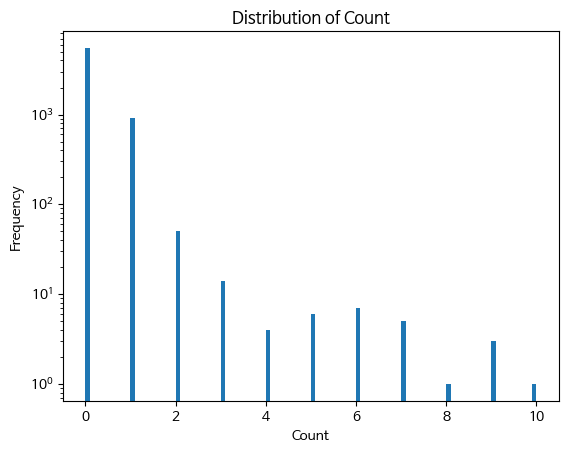

In [ ]:
df_nc =df[df['nonverbal_count']<20]
plt.hist(df_nc['nonverbal_count'], bins=100)
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.title('Distribution of Count')
plt.yscale('log')
plt.show()
df[df['nonverbal_count']>5]   ##이모티콘 수가 6개 이상일때 모든 채팅이 프로그래밍코드이거나 도배글임

df.loc[df['nonverbal_count']>5,'nonverbal']= ''
df['nonverbal_count'] = df['nonverbal'].apply(len)


## 응답시간 구하기


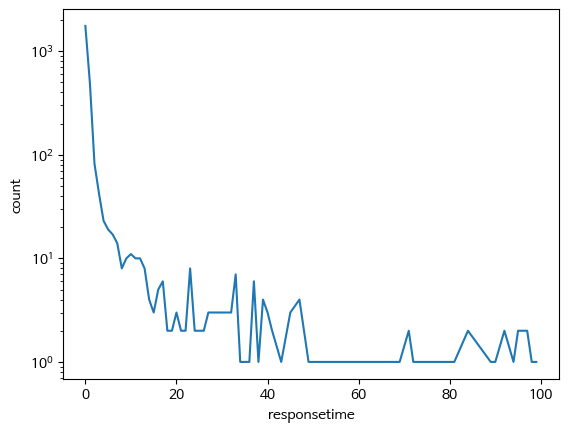

In [ ]:
df['response_time']=df['date_time'].diff() ##이전 행의 시간과 현재행의 시간을 비교해서 현재행에 넣음
df['is_first_talk'] = 0 ##일단은 선톡이 아니라고 해놓고 선톡인 애들은 1로 바꿔줌
df.loc[df['response_time'] < pd.Timedelta(0), 'is_first_talk']=1 # 그사람과의 첫채팅은 선톡이니 1로 바꿔줌
df.loc[0, 'is_first_talk']=1
df.loc[df['response_time'] < pd.Timedelta(0), 'response_time'] = np.nan ##response_time이 음수인경우) chat_room_name이 바뀌면 아예 다른 대화니까  none으로 처리
df.loc[df['user_name'].shift() == df['user_name'], 'response_time'] = np.nan  ## 자기가 계속 한 말은 서로의 응답시간 체크가 필요없으므로 none으로 처리
df['response_time']=df['response_time'].astype('timedelta64[m]')     ##분 단위로 바꿔줌

#df_res=df[~pd.isna(df['response_time'])] #응답시간이 null이 아닌것만 뽑음


#response_time_count =df_res['response_time'].value_counts().sort_index()

# for i in response_time_count.index: # 응답시간에 제한을 걸고 걸엇을때의 갯수가 전체의 몇개인지 구분
#    limit = i
#    test= response_time_count[response_time_count.index<=limit]
#    print("최대 응답속도: %.f분, 전체 응답속도 갯수: %.f, 제한한 응답속도 갯수: %.f (전체의 %.3f%%)"%(limit,response_time_count.sum(),test.sum(),test.sum()/response_time_count.sum()*100))

test= response_time_count[response_time_count.index<=100]   #로그스케일로 그리다보니까 50~70분에 값이 거의 없는 것을 발견

plt.plot(test.index,test.values)
plt.xlabel('responsetime')
plt.ylabel('count')
plt.yscale('log')
plt.show()

#새로운 대화는 특정시간마다 시작되지 않고 랜덤하게 시작된다. 그러므로 한 시간대에 응답속도가 들어간 메시지의 갯수가 많다면 그 시간대는 전 채팅에 대한 답변일 것이다.
#그래프로 그리고 표로 보았을때 49분부터 메세지의 갯수가 1에 가까웠다. 그러므로 다음 채팅을 판단하는 기준은 49분으로 정한다.

#####선톡인지 추가
df.loc[df['response_time']>=49,'is_first_talk']= 1


df.loc[df['response_time']>=49,'response_time']=np.nan #응답시간이 49분 이상인 경우 none으로 처리



##감정분석


##피클로 데이터프레임 저장

In [ ]:
df.to_pickle(os.path.join(f_path, "katalk_data_merged.pkl"))

##df = pd.read_pickle(os.path.join(f_path, "katalk_data_merged.pkl"))
df

,date_time,user_name,text,친밀도 순위,chat_room_name,msg_len,msg_word_count,audio_visual,nonverbal,nonverbal_count,url,url_count,response_time,is_first_talk
0,2022-08-03 10:32:00,송창훈,헬푸,1,서민호,2,1,0.0,[],0,[],0,NaN,0
1,2022-08-03 10:34:00,송창훈,이번학기에,1,서민호,5,1,0.0,[],0,[],0,NaN,0
2,2022-08-03 10:35:00,송창훈,너 19학점 들엇잖음,1,서민호,11,3,0.0,[],0,[],0,NaN,0
3,2022-08-03 10:35:00,송창훈,강원문화사 3학점이랑,1,서민호,11,2,0.0,[],0,[],0,NaN,0
4,2022-08-03 10:35:00,송창훈,그 실사구시 먼가 그거,1,서민호,12,4,0.0,[],0,[],0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6339,2023-05-18 19:53:00,송창훈,충분해여,10,아빠,4,1,0.0,[],0,[],0,4.0,0
6340,2023-05-18 19:53:00,송창훈,감사합니다,10,아빠,5,1,0.0,[],0,[],0,NaN,0
6341,2023-05-18 19:54:00,아빠,이모티콘,10,아빠,4,1,0.0,[],0,[],0,1.0,0
6342,2023-05-21 07:51:00,아빠,이모티콘,10,아빠,4,1,0.0,[],0,[],0,NaN,0


#데이터 분석

In [ ]:
result =pd.DataFrame({'상대방':list(files)})  ##files : 이름이 들어있는 집합

rank_count =1
for f in files:
  result.loc[result['상대방'] == f, '채팅량'] = df[(df['chat_room_name'] == f)].shape[0] ##말풍선 갯수

  result.loc[result['상대방'] == f, '대화 횟수'] = df[(df['chat_room_name'] == f) & (~pd.isna(df['response_time']))].shape[0] ##말을 주고 받고 한 횟수

  result.loc[result['상대방'] == f, '채팅량 비율(나)'] = df[(df['chat_room_name'] == f)&(df['user_name']==myname)].shape[0] /df[(df['chat_room_name'] == f)].shape[0] ##내 채팅 수/ 전체 채팅 수

  result.loc[result['상대방'] == f, '평균답장속도(분)'] = df.loc[(df['chat_room_name'] == f),'response_time'].mean()

  result.loc[result['상대방'] == f, '선톡  비율(나)'] = df[(df['chat_room_name'] == f)&(df['is_first_talk']==1)&(df['user_name']==myname)].shape[0]/df[(df['chat_room_name'] == f)&(df['is_first_talk']==1)].shape[0] ##내 선톡/ 전체 선톡

  result.loc[result['상대방'] == f, '한 채팅당 평균 길이'] =(df.loc[df['chat_room_name']==f,'msg_len'].sum())    /  (len(df[df['chat_room_name']==f]))

  result.loc[result['상대방'] == f, '상대방의 한 채팅당 평균 길이'] =(df.loc[(df['chat_room_name']==f)&(df['user_name']==f),'msg_len'].sum())    /  (len(df[(df['chat_room_name']==f)&(df['user_name']==f)]))

  result.loc[result['상대방'] == f, '나의 한 채팅당 평균 길이'] =(df.loc[(df['chat_room_name']==f)&(df['user_name']==myname),'msg_len'].sum())    /  (len(df[(df['chat_room_name']==f)&(df['user_name']==myname)]))

  result.loc[result['상대방'] == f, '한 채팅당 비언어표현 사용 수']= df.loc[(df['chat_room_name']==f),'nonverbal_count'].sum()/df[(df['chat_room_name'] == f)].shape[0]

  result.loc[result['상대방'] == f, '한 채팅당 url 수']= df.loc[(df['chat_room_name']==f),'url_count'].sum()/df[(df['chat_room_name'] == f)].shape[0]

  result.loc[result['상대방'] == f, '한 채팅당 사진,동영상 수']= df.loc[(df['chat_room_name']==f),'audio_visual'].sum()/df[(df['chat_room_name'] == f)].shape[0]

  result.loc[result['상대방'] == f, '친밀도 순위']= rank_count
  rank_count+=1






test_result= result[result['상대방']==test_name]
result=result[result['상대방']!=test_name]

result

,상대방,채팅량,대화 횟수,채팅량 비율(나),평균답장속도(분),선톡 비율(나),한 채팅당 평균 길이,상대방의 한 채팅당 평균 길이,나의 한 채팅당 평균 길이,한 채팅당 비언어표현 사용 수,한 채팅당 url 수,"한 채팅당 사진,동영상 수",친밀도 순위
0,서민호,298.0,114.0,0.583893,0.894737,0.600000,5.771812,5.274194,6.126437,0.097315,0.003356,0.067114,1.0
1,이도현,547.0,248.0,0.522852,0.427419,0.666667,11.597806,13.521073,9.842657,0.096892,0.014625,0.014625,2.0
2,오진우,514.0,199.0,0.710117,2.055276,0.619048,5.854086,5.033557,6.189041,0.167315,0.003891,0.031128,3.0
3,김세현,816.0,333.0,0.471814,1.894895,0.413793,9.888480,11.283063,8.327273,0.164216,0.006127,0.026961,4.0
4,김도윤,895.0,388.0,0.491620,0.628866,0.833333,7.661453,6.593407,8.765909,0.154190,0.007821,0.012291,5.0
5,허지환,607.0,228.0,0.525535,1.337719,0.388889,9.751236,7.013889,12.222571,0.136738,0.003295,0.051071,6.0
6,오승환,1342.0,528.0,0.505216,2.034091,0.382353,19.311475,18.936747,19.678466,0.211624,0.002981,0.040984,7.0
7,유승원,275.0,146.0,0.570909,0.253425,0.333333,8.327273,8.872881,7.917197,0.120000,0.014545,0.018182,8.0
8,엄마,792.0,335.0,0.468434,3.244776,0.600000,19.258838,25.092637,12.638814,0.222222,0.007576,0.084596,9.0
9,아빠,258.0,72.0,0.248062,5.847222,0.458333,13.860465,14.737113,11.203125,0.182171,0.000000,0.120155,10.0


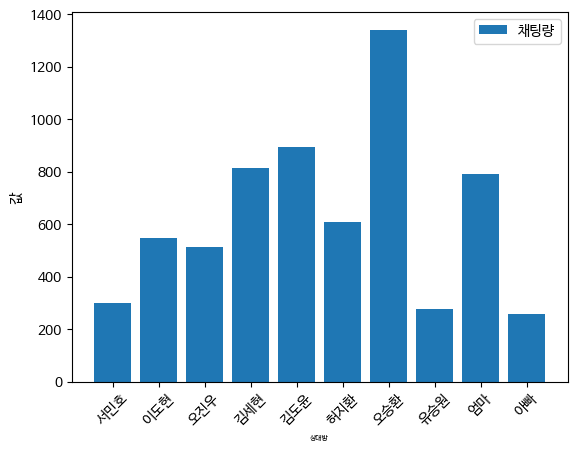

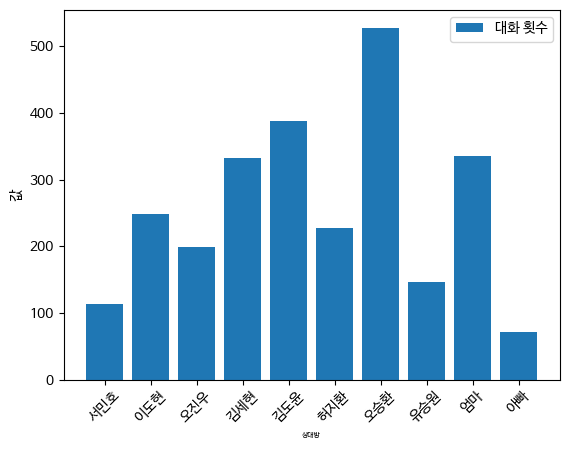

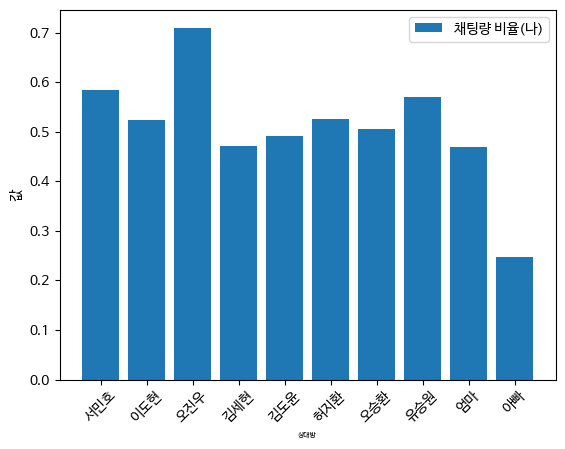

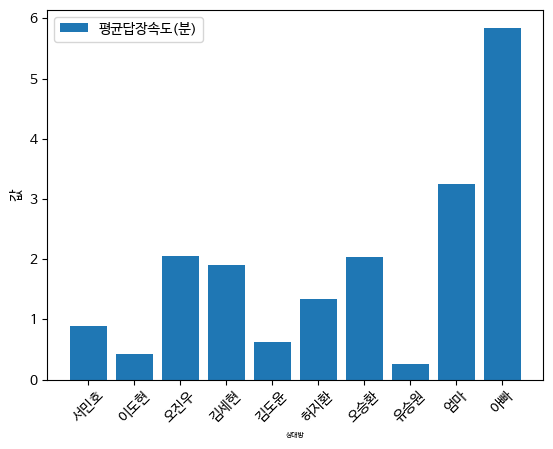

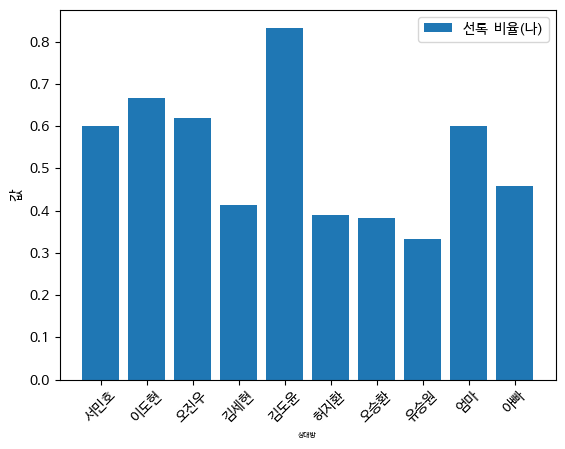

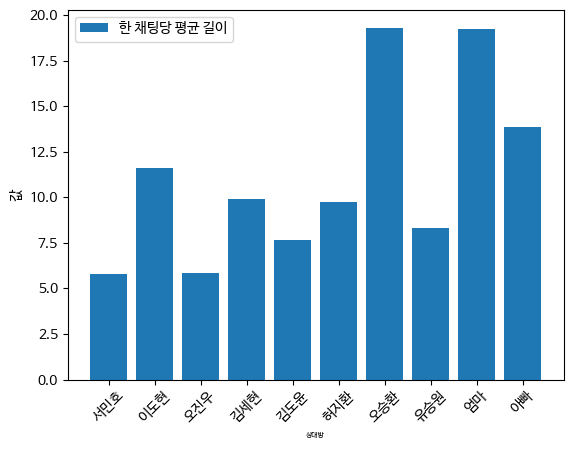

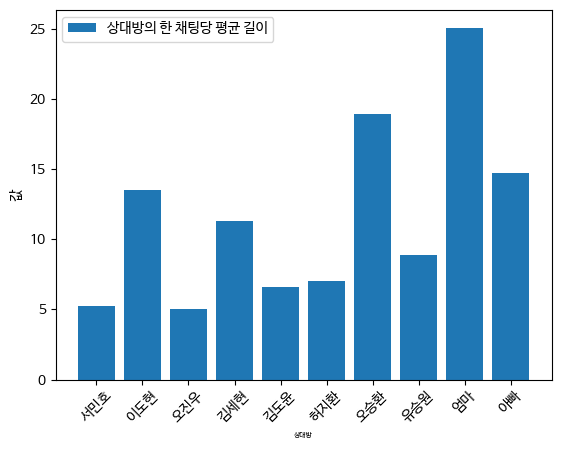

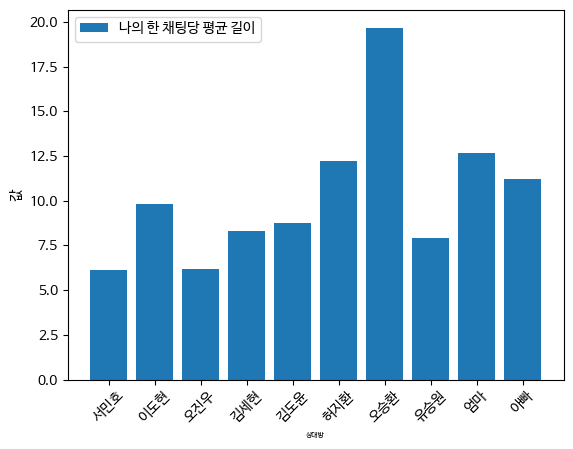

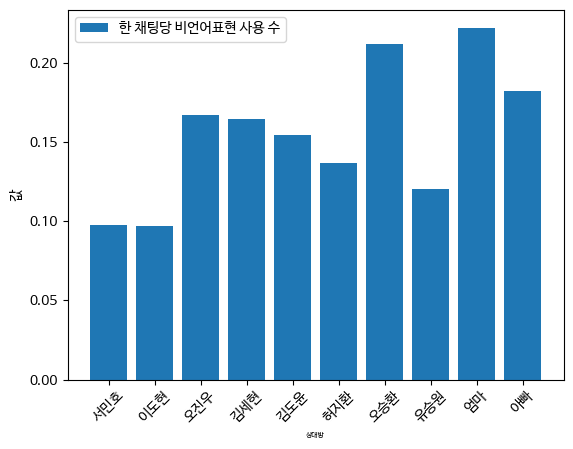

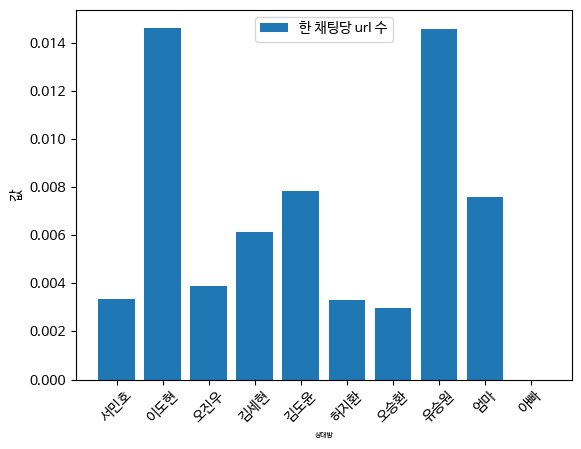

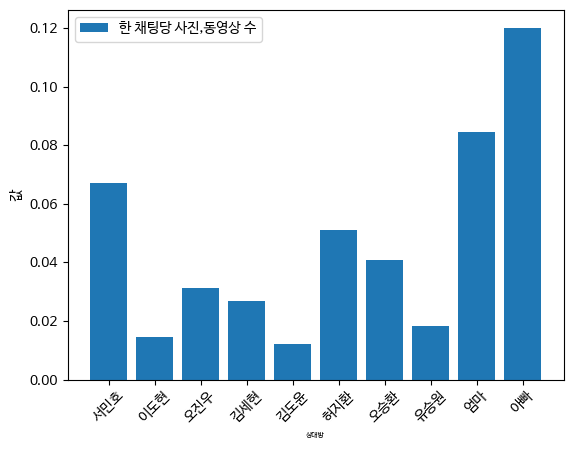

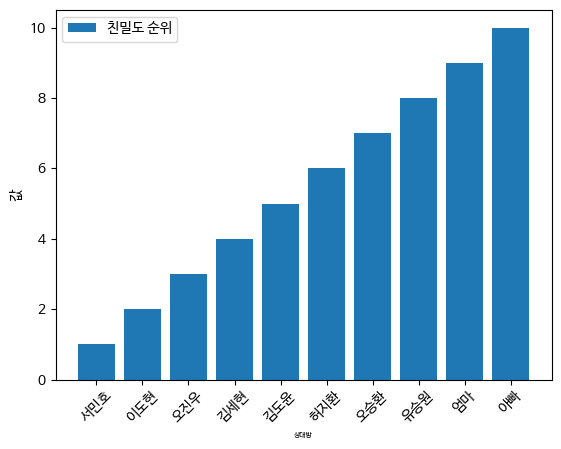

In [ ]:

plt.rc('font', family='NanumBarunGothic')


x = result['상대방']  # x축으로 사용할 열 선택 (여기서는 '상대방' 열)
for column in result.columns:
    if column != '상대방':  # '상대방' 열은 이미 x축으로 사용했으므로 건너뜀
        y = result[column]
        plt.bar(x, y, label=column)
        plt.xlabel('상대방',fontsize=5)  # x축 레이블 설정
        plt.ylabel('값')  # y축 레이블 설정
        plt.rc('xtick', labelsize=10)
        plt.xticks(rotation=45)
        plt.legend()  # 범례 표시
        plt.show()


<ipython-input-170-1698c13110cd>:1: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



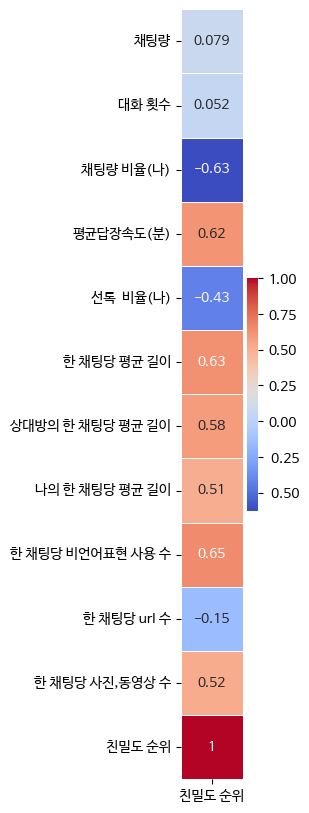

In [ ]:
correlation_matrix = result.corr()

# 시각화 설정
plt.figure(figsize=(1, 10))
sns.heatmap(correlation_matrix.iloc[:, 11:12], annot=True, cmap='coolwarm', linewidths=0.5)

# 그래프 출력
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
result_std = pd.DataFrame(result)

result_std =  pd.DataFrame(scaler.fit_transform(result_std.drop(['상대방'],axis=1)),columns=result_std.drop(['상대방'],axis=1).columns)

##result_std= result_std[['채팅량 비율(나)','평균답장속도(분)','한 채팅당 평균 길이','한 채팅당 비언어표현 사용 수','친밀도 순위']]               ######feauture selection


## 테스트용 추가 파일에 대한 스케일링

if test_name != None:
  test_result_std = pd.DataFrame(test_result)
  test_result_std = pd.DataFrame(scaler.transform(test_result_std.drop(['상대방'],axis=1)),columns=test_result_std.drop(['상대방'],axis=1).columns)

  ##test_result_std= test_result_std[['채팅량 비율(나)','평균답장속도(분)','한 채팅당 평균 길이','한 채팅당 비언어표현 사용 수']]



result_std

,채팅량,대화 횟수,채팅량 비율(나),평균답장속도(분),선톡 비율(나),한 채팅당 평균 길이,상대방의 한 채팅당 평균 길이,나의 한 채팅당 평균 길이,한 채팅당 비언어표현 사용 수,한 채팅당 url 수,"한 채팅당 사진,동영상 수",친밀도 순위
0,0.036900,0.092105,0.726820,0.114647,0.533333,0.000000,0.011996,0.000000,0.003377,0.229446,0.508263,0.000000
1,0.266605,0.385965,0.594713,0.031105,0.666667,0.430291,0.423126,0.274219,0.000000,1.000000,0.021645,0.111111
2,0.236162,0.278509,1.000000,0.322116,0.571429,0.006076,0.000000,0.004620,0.561900,0.266051,0.174644,0.222222
3,0.514760,0.572368,0.484254,0.293445,0.160920,0.304045,0.311555,0.162399,0.537170,0.418964,0.136007,0.333333
4,0.587638,0.692982,0.527120,0.067117,1.000000,0.139563,0.077763,0.194766,0.457175,0.534777,0.000000,0.444444
5,0.321956,0.342105,0.600521,0.193839,0.111111,0.293909,0.098725,0.449832,0.317928,0.225288,0.359528,0.555556
6,1.000000,1.000000,0.556545,0.318329,0.098039,1.000000,0.693112,1.000000,0.915441,0.203800,0.266011,0.666667
7,0.015683,0.162281,0.698720,0.000000,0.000000,0.188739,0.191401,0.132140,0.184376,0.994545,0.054618,0.777778
8,0.492620,0.576754,0.476940,0.534762,0.533333,0.996112,1.000000,0.480546,1.000000,0.517992,0.670336,0.888889
9,0.000000,0.000000,0.000000,1.000000,0.250000,0.597404,0.483749,0.374607,0.680430,0.000000,1.000000,1.000000


In [ ]:
from sklearn.model_selection import train_test_split

X= result_std.drop(['친밀도 순위'],axis=1)

y=result['친밀도 순위']

X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1111)



In [ ]:
from sklearn.linear_model import LinearRegression

LR = LinearRegression()

LR.fit(X_train, y_train)

y_prediction = LR.predict(X_test)

from sklearn.metrics import r2_score #metric == 지표
from sklearn.metrics import mean_squared_error

score = r2_score(y_test,y_prediction)

print('r2 score is %.4f'%score)
print('root_mean_squared error of is %.2f'%np.sqrt(mean_squared_error(y_test,y_prediction)))

r2 score is -1.9783
root_mean_squared error of is 5.18


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
importance = rf.feature_importances_

y_prediction = rf.predict(X_test)

score = r2_score(y_test,y_prediction)

print('r2 score is %.4f'%score)
print('root_mean_squared error of is %.2f'%np.sqrt(mean_squared_error(y_test,y_prediction)))

for i, val in enumerate(importance):
    print(f"Feature {i+1}: {val}")

r2 score is -0.1556
root_mean_squared error of is 3.22
Feature 1: 0.09754849572907698
Feature 2: 0.03359401986491167
Feature 3: 0.020763457684940922
Feature 4: 0.052934973672504035
Feature 5: 0.21167681090219986
Feature 6: 0.07588636553725638
Feature 7: 0.13031776119783436
Feature 8: 0.05293140047902663
Feature 9: 0.23208472771639366
Feature 10: 0.05743434761669703
Feature 11: 0.03482763959915855


<ipython-input-180-fa81a29b5f19>:2: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



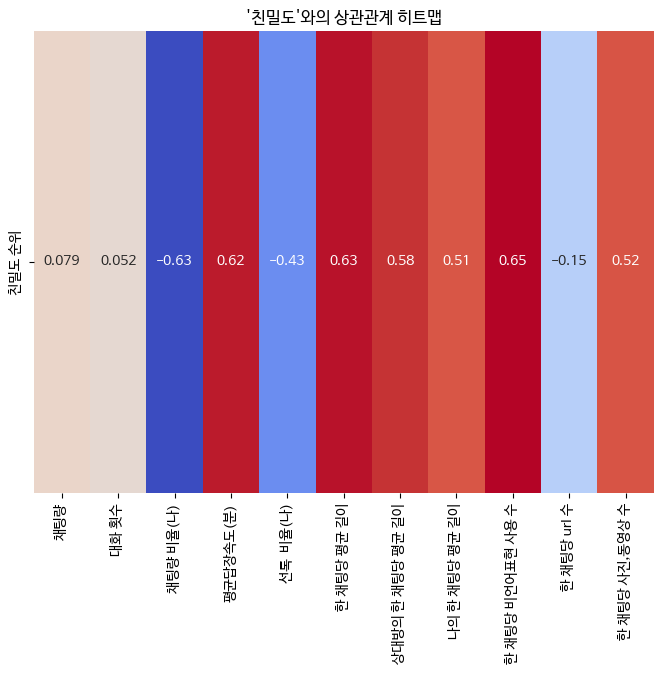

In [ ]:
import seaborn as sns
correlation_matrix = result.corr()

correlation_with_target = correlation_matrix['친밀도 순위'].drop('친밀도 순위')

# 히트맵 그리기
plt.figure(figsize=(8, 6))  # 히트맵 크기 설정
sns.heatmap(correlation_with_target.to_frame().T, annot=True, cmap='coolwarm', cbar=False)

plt.title("'친밀도'와의 상관관계 히트맵")  # 히트맵 제목 설정
plt.show()